In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv('Social_Network_Ads.csv')

In [5]:
x=df[['Age','EstimatedSalary']]
y=df['Purchased']

## feature scaling

In [14]:

from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
x_scaled=scaler.fit_transform(x)

## Cross Validation

In [16]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x_scaled,y,random_state=0)

## build the model

In [20]:
from sklearn.neighbors import KNeighborsClassifier

In [22]:
knn=KNeighborsClassifier(n_neighbors=4)

In [24]:
knn.fit(x_train,y_train)

KNeighborsClassifier(n_neighbors=4)

## EVALUATE MODEL

In [113]:
from sklearn.metrics import ConfusionMatrixDisplay,accuracy_score,classification_report
y_pred=knn.predict(x_test)
accuracy_score(y_test,y_pred)

0.93

In [31]:
## TO check how many values are error rate
np.mean(y_test != y_pred)

0.08

In [47]:

for i in range(30):
    n_neighbors=i
    knn=KNeighborsClassifier(n_neighbors=4)
    knn.fit(x_train,y_train)
    y_pred=knn.predict(x_test)
    print(i,
    accuracy_score(y_test,y_pred))

0 0.92
1 0.92
2 0.92
3 0.92
4 0.92
5 0.92
6 0.92
7 0.92
8 0.92
9 0.92
10 0.92
11 0.92
12 0.92
13 0.92
14 0.92
15 0.92
16 0.92
17 0.92
18 0.92
19 0.92
20 0.92
21 0.92
22 0.92
23 0.92
24 0.92
25 0.92
26 0.92
27 0.92
28 0.92
29 0.92


## HOW TO FIND PROPER VALUE OF K

In [57]:
error=[]

for k in range(1,101):
    knn=KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train,y_train)
    y_pred=knn.predict(x_test)
    #error rate
    error.append(np.mean(y_test!=y_pred))
error

[0.11,
 0.1,
 0.07,
 0.08,
 0.07,
 0.07,
 0.07,
 0.07,
 0.07,
 0.07,
 0.07,
 0.07,
 0.07,
 0.07,
 0.07,
 0.07,
 0.07,
 0.07,
 0.07,
 0.07,
 0.07,
 0.07,
 0.07,
 0.07,
 0.07,
 0.07,
 0.07,
 0.07,
 0.07,
 0.07,
 0.07,
 0.07,
 0.07,
 0.07,
 0.07,
 0.07,
 0.07,
 0.07,
 0.07,
 0.08,
 0.08,
 0.08,
 0.08,
 0.09,
 0.08,
 0.09,
 0.08,
 0.08,
 0.08,
 0.09,
 0.08,
 0.09,
 0.08,
 0.1,
 0.09,
 0.1,
 0.1,
 0.1,
 0.1,
 0.11,
 0.1,
 0.11,
 0.11,
 0.11,
 0.11,
 0.11,
 0.11,
 0.11,
 0.11,
 0.12,
 0.12,
 0.12,
 0.11,
 0.12,
 0.12,
 0.11,
 0.11,
 0.11,
 0.11,
 0.12,
 0.12,
 0.12,
 0.12,
 0.13,
 0.13,
 0.13,
 0.13,
 0.13,
 0.13,
 0.13,
 0.13,
 0.14,
 0.13,
 0.13,
 0.13,
 0.15,
 0.14,
 0.15,
 0.15,
 0.15]

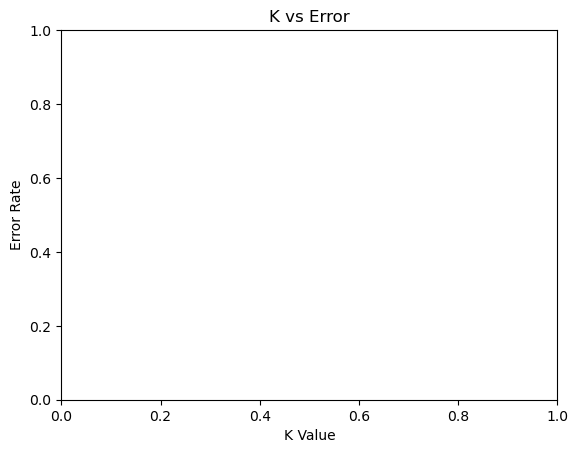

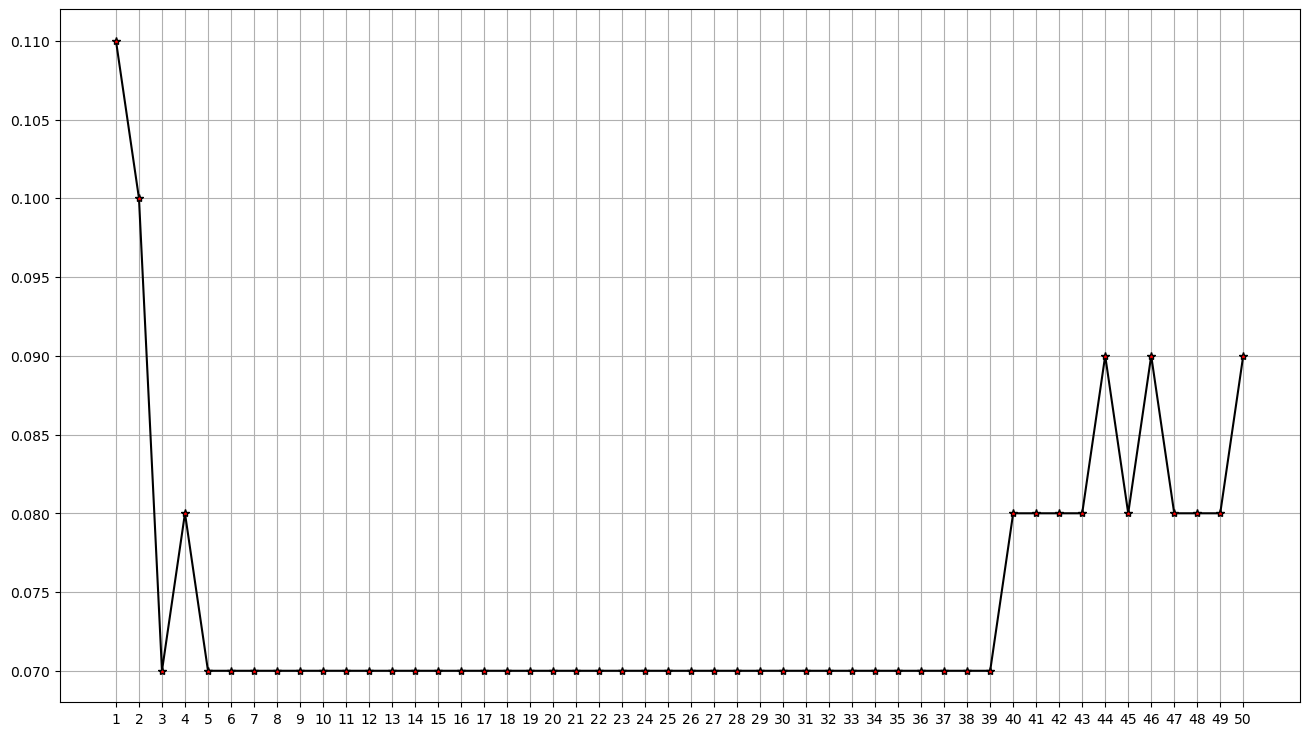

In [99]:
plt.title('K vs Error')
plt.xlabel('K Value')
plt.ylabel('Error Rate')
plt.figure(figsize=(16,9))
k=np.arange(1,51,1)
plt.xticks(range(1,51,1))
plt.plot(k ,error[:50],color='Black',mfc='red',marker='*')
plt.grid()

In [93]:
#check accuracy with value 3
knn=KNeighborsClassifier(n_neighbors=3)
knn.fit(x_train,y_train)
y_pred=knn.predict(x_test)
print(accuracy_score(y_test,y_pred))

0.93


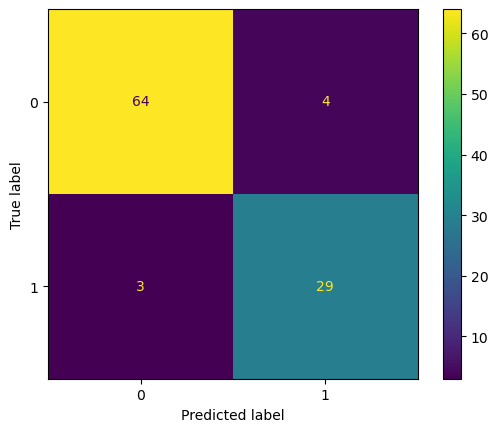

In [101]:
ConfusionMatrixDisplay.from_predictions(y_test,y_pred)

In [103]:
accuracy_score(y_test,y_pred)

0.93

In [117]:
classification_report(y_test,y_pred)

'              precision    recall  f1-score   support\n\n           0       0.96      0.94      0.95        68\n           1       0.88      0.91      0.89        32\n\n    accuracy                           0.93       100\n   macro avg       0.92      0.92      0.92       100\nweighted avg       0.93      0.93      0.93       100\n'